In [43]:
import numpy as np
import pandas as pd
import sklearn.impute , sklearn.preprocessing
import seaborn 
import matplotlib.pyplot as plt

In [44]:
data_train = pd.read_excel('../data/processed/disaster_prediction_train.xlsx')
data_train

,historic,disaster_type,country,region,magnitude,magnitude_scale,latitude,longitude,start_year,start_month
0,Yes,Flood,United States of America,Americas,NaN,Km2,NaN,NaN,1977,9.0
1,No,Drought,Ethiopia,Africa,NaN,Km2,NaN,NaN,2021,5.0
2,No,Storm,China,Asia,NaN,Kph,NaN,NaN,2014,8.0
3,No,Wildfire,Viet Nam,Asia,55.0,Km2,NaN,NaN,2002,3.0
4,No,Earthquake,El Salvador,Americas,6.6,Moment Magnitude,13.671,-88.938,2001,2.0
...,...,...,...,...,...,...,...,...,...,...
12424,Yes,Earthquake,Libya,Africa,5.4,Moment Magnitude,32.600,21.000,1963,2.0
12425,No,Flood,South Africa,Africa,NaN,Km2,NaN,NaN,2019,5.0
12426,Yes,Extreme temperature,India,Asia,NaN,°C,NaN,NaN,1985,12.0
12427,No,Storm,Oman,Asia,NaN,Kph,NaN,NaN,2003,4.0


In [45]:
data_test = pd.read_excel('../data/processed/disaster_prediction_test.xlsx')
data_test

,historic,disaster_type,country,region,magnitude,magnitude_scale,latitude,longitude,start_year,start_month
0,No,Flood,Malaysia,Asia,NaN,Km2,NaN,NaN,2003,10.0
1,No,Flood,Peru,Americas,NaN,Km2,NaN,NaN,2015,4.0
2,No,Flood,Guinea,Africa,NaN,Km2,NaN,NaN,2024,7.0
3,No,Wildfire,Nepal,Asia,NaN,Km2,NaN,NaN,2016,2.0
4,No,Storm,India,Asia,110.0,Kph,NaN,NaN,2009,5.0
...,...,...,...,...,...,...,...,...,...,...
5322,Yes,Earthquake,Türkiye,Asia,6.0,Moment Magnitude,41.7,43.8,1940,5.0
5323,No,Flood,Indonesia,Asia,NaN,Km2,NaN,NaN,2014,1.0
5324,Yes,Drought,Côte d’Ivoire,Africa,NaN,Km2,NaN,NaN,1983,NaN
5325,No,Flood,Iran (Islamic Republic of),Asia,NaN,Km2,NaN,NaN,2017,8.0


In [46]:
data_train.isnull().mean()*100

historic            0.000000
disaster_type       0.000000
country             0.000000
region              0.000000
magnitude          70.094135
magnitude_scale    11.754767
latitude           83.932738
longitude          83.932738
start_year          0.000000
start_month         2.124065
dtype: float64

In [47]:
data_train.info(0)

<class 'pandas.DataFrame'>
RangeIndex: 12429 entries, 0 to 12428
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   historic         12429 non-null  str    
 1   disaster_type    12429 non-null  str    
 2   country          12429 non-null  str    
 3   region           12429 non-null  str    
 4   magnitude        3717 non-null   float64
 5   magnitude_scale  10968 non-null  str    
 6   latitude         1997 non-null   float64
 7   longitude        1997 non-null   float64
 8   start_year       12429 non-null  int64  
 9   start_month      12165 non-null  float64
dtypes: float64(4), int64(1), str(5)
memory usage: 971.1 KB


In [48]:
data_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 5327 entries, 0 to 5326
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   historic         5327 non-null   str    
 1   disaster_type    5327 non-null   str    
 2   country          5327 non-null   str    
 3   region           5327 non-null   str    
 4   magnitude        1571 non-null   float64
 5   magnitude_scale  4685 non-null   str    
 6   latitude         836 non-null    float64
 7   longitude        836 non-null    float64
 8   start_year       5327 non-null   int64  
 9   start_month      5219 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 416.3 KB


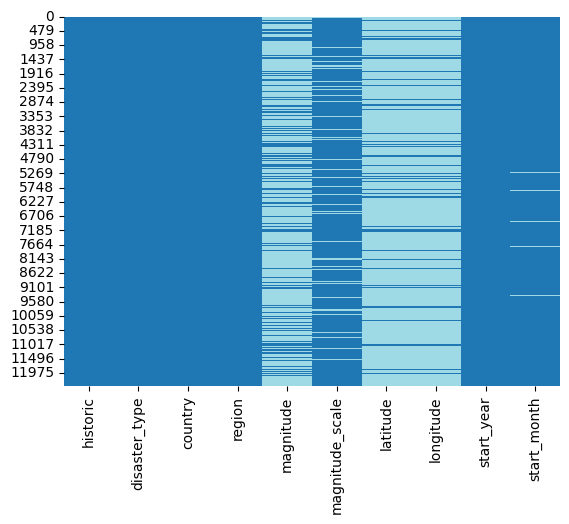

In [49]:
seaborn.heatmap(data_train.isnull(),cbar=False,cmap='tab20')
plt.show()

In [50]:
data_train.isnull().sum()

historic               0
disaster_type          0
country                0
region                 0
magnitude           8712
magnitude_scale     1461
latitude           10432
longitude          10432
start_year             0
start_month          264
dtype: int64

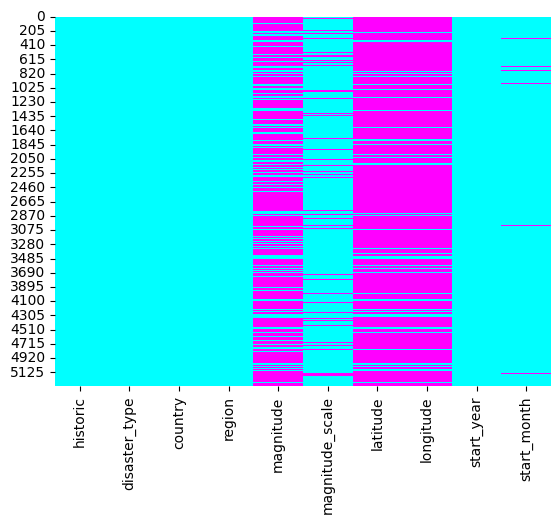

In [51]:
seaborn.heatmap(data_test.isnull(),cbar=False,cmap='cool')
plt.show()

In [52]:
data_test.isnull().sum()

historic              0
disaster_type         0
country               0
region                0
magnitude          3756
magnitude_scale     642
latitude           4491
longitude          4491
start_year            0
start_month         108
dtype: int64

In [53]:
data_train['disaster_type'].value_counts()

disaster_type
Flood                  4328
Storm                  3537
Earthquake             1156
Epidemic               1135
Landslide               643
Drought                 562
Extreme temperature     511
Wildfire                360
Volcanic activity       197
Name: count, dtype: int64

In [54]:
data_test['disaster_type'].value_counts()

disaster_type
Flood                  1855
Storm                  1516
Earthquake              495
Epidemic                487
Landslide               275
Drought                 241
Extreme temperature     219
Wildfire                154
Volcanic activity        85
Name: count, dtype: int64

In [55]:
data_train['disaster_type'].value_counts(normalize=True) * 100

disaster_type
Flood                  34.821788
Storm                  28.457639
Earthquake              9.300829
Epidemic                9.131869
Landslide               5.173385
Drought                 4.521683
Extreme temperature     4.111352
Wildfire                2.896452
Volcanic activity       1.585003
Name: proportion, dtype: float64

In [56]:
data_test['disaster_type'].value_counts(normalize=True) * 100

disaster_type
Flood                  34.822602
Storm                  28.458795
Earthquake              9.292285
Epidemic                9.142106
Landslide               5.162380
Drought                 4.524122
Extreme temperature     4.111132
Wildfire                2.890933
Volcanic activity       1.595645
Name: proportion, dtype: float64

In [57]:
# handling missing values
from sklearn.impute import SimpleImputer

In [58]:
# separate it first
X_train = data_train.drop("disaster_type", axis=1)
y_train = data_train["disaster_type"]

X_test = data_test.drop("disaster_type", axis=1)
y_test = data_test["disaster_type"]

In [59]:

categorical_features_train = data_train.select_dtypes(include=['object', 'category']).columns
categorical_features_train

C:\Users\ACER\AppData\Local\Temp\ipykernel_5764\2418594763.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_train = data_train.select_dtypes(include=['object', 'category']).columns


Index(['historic', 'disaster_type', 'country', 'region', 'magnitude_scale'], dtype='str')

In [60]:
categorical_features_test = data_test.select_dtypes(include=['object', 'category']).columns
categorical_features_test

C:\Users\ACER\AppData\Local\Temp\ipykernel_5764\3072890133.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_test = data_test.select_dtypes(include=['object', 'category']).columns


Index(['historic', 'disaster_type', 'country', 'region', 'magnitude_scale'], dtype='str')

In [61]:
categorical_features_data_train = data_train[categorical_features_train]
categorical_features_data_train

,historic,disaster_type,country,region,magnitude_scale
0,Yes,Flood,United States of America,Americas,Km2
1,No,Drought,Ethiopia,Africa,Km2
2,No,Storm,China,Asia,Kph
3,No,Wildfire,Viet Nam,Asia,Km2
4,No,Earthquake,El Salvador,Americas,Moment Magnitude
...,...,...,...,...,...
12424,Yes,Earthquake,Libya,Africa,Moment Magnitude
12425,No,Flood,South Africa,Africa,Km2
12426,Yes,Extreme temperature,India,Asia,°C
12427,No,Storm,Oman,Asia,Kph


In [62]:
categorical_features_data_test = data_test[categorical_features_test]
categorical_features_data_test

,historic,disaster_type,country,region,magnitude_scale
0,No,Flood,Malaysia,Asia,Km2
1,No,Flood,Peru,Americas,Km2
2,No,Flood,Guinea,Africa,Km2
3,No,Wildfire,Nepal,Asia,Km2
4,No,Storm,India,Asia,Kph
...,...,...,...,...,...
5322,Yes,Earthquake,Türkiye,Asia,Moment Magnitude
5323,No,Flood,Indonesia,Asia,Km2
5324,Yes,Drought,Côte d’Ivoire,Africa,Km2
5325,No,Flood,Iran (Islamic Republic of),Asia,Km2


In [63]:
data_train.isnull().mean()*100

historic            0.000000
disaster_type       0.000000
country             0.000000
region              0.000000
magnitude          70.094135
magnitude_scale    11.754767
latitude           83.932738
longitude          83.932738
start_year          0.000000
start_month         2.124065
dtype: float64

In [64]:
categorical_impute= SimpleImputer(strategy='most_frequent')
categorical_impute

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [65]:
categorical_impute.fit(categorical_features_data_train)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [66]:
categorical_features_data_train = pd.DataFrame(
    data = categorical_impute.transform(categorical_features_data_train),
    columns = categorical_impute.get_feature_names_out(),
    index = categorical_features_data_train.index
)
categorical_features_data_train

,historic,disaster_type,country,region,magnitude_scale
0,Yes,Flood,United States of America,Americas,Km2
1,No,Drought,Ethiopia,Africa,Km2
2,No,Storm,China,Asia,Kph
3,No,Wildfire,Viet Nam,Asia,Km2
4,No,Earthquake,El Salvador,Americas,Moment Magnitude
...,...,...,...,...,...
12424,Yes,Earthquake,Libya,Africa,Moment Magnitude
12425,No,Flood,South Africa,Africa,Km2
12426,Yes,Extreme temperature,India,Asia,°C
12427,No,Storm,Oman,Asia,Kph


In [67]:
categorical_features_data_test = pd.DataFrame(
    data = categorical_impute.transform(categorical_features_data_test),
    columns = categorical_impute.get_feature_names_out(),
    index = categorical_features_data_test.index
)
categorical_features_data_test

,historic,disaster_type,country,region,magnitude_scale
0,No,Flood,Malaysia,Asia,Km2
1,No,Flood,Peru,Americas,Km2
2,No,Flood,Guinea,Africa,Km2
3,No,Wildfire,Nepal,Asia,Km2
4,No,Storm,India,Asia,Kph
...,...,...,...,...,...
5322,Yes,Earthquake,Türkiye,Asia,Moment Magnitude
5323,No,Flood,Indonesia,Asia,Km2
5324,Yes,Drought,Côte d’Ivoire,Africa,Km2
5325,No,Flood,Iran (Islamic Republic of),Asia,Km2


In [68]:
categorical_features_data_train.isnull().sum()

historic           0
disaster_type      0
country            0
region             0
magnitude_scale    0
dtype: int64

In [69]:

categorical_features_data_test.isnull().sum()

historic           0
disaster_type      0
country            0
region             0
magnitude_scale    0
dtype: int64

In [70]:
numerical_features = [
    'magnitude',
    'latitude',
    'longitude',
    'start_year',
    'start_month',
]

In [71]:
numerical_features_data_train = data_train[numerical_features]
numerical_features_data_train

,magnitude,latitude,longitude,start_year,start_month
0,NaN,NaN,NaN,1977,9.0
1,NaN,NaN,NaN,2021,5.0
2,NaN,NaN,NaN,2014,8.0
3,55.0,NaN,NaN,2002,3.0
4,6.6,13.671,-88.938,2001,2.0
...,...,...,...,...,...
12424,5.4,32.600,21.000,1963,2.0
12425,NaN,NaN,NaN,2019,5.0
12426,NaN,NaN,NaN,1985,12.0
12427,NaN,NaN,NaN,2003,4.0


In [72]:

numerical_features_data_test = data_test[numerical_features]
numerical_features_data_test

,magnitude,latitude,longitude,start_year,start_month
0,NaN,NaN,NaN,2003,10.0
1,NaN,NaN,NaN,2015,4.0
2,NaN,NaN,NaN,2024,7.0
3,NaN,NaN,NaN,2016,2.0
4,110.0,NaN,NaN,2009,5.0
...,...,...,...,...,...
5322,6.0,41.7,43.8,1940,5.0
5323,NaN,NaN,NaN,2014,1.0
5324,NaN,NaN,NaN,1983,NaN
5325,NaN,NaN,NaN,2017,8.0


In [73]:
# add missing indicators
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')

missing_flags = indicator.fit_transform(numerical_features_data_train[['magnitude','latitude','longitude']])

In [74]:
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')

missing_flags = indicator.fit_transform(numerical_features_data_test[['magnitude','latitude','longitude']])

In [75]:
# impute values
from sklearn.impute import KNNImputer

In [76]:
imputer = KNNImputer(n_neighbors=5)

num_cols = ['magnitude','latitude','longitude','start_year','start_month']
numerical_features_data_train[num_cols] = imputer.fit_transform(numerical_features_data_train[num_cols])

In [77]:
imputer = KNNImputer(n_neighbors=5)

num_cols = ['magnitude','latitude','longitude','start_year','start_month']
numerical_features_data_test[num_cols] = imputer.fit_transform(numerical_features_data_test[num_cols])

In [79]:
numerical_features_data_train.isna().sum(axis='index')

magnitude      0
latitude       0
longitude      0
start_year     0
start_month    0
dtype: int64

In [80]:
categorical_features_data_train.isna().sum(axis='index')

historic           0
disaster_type      0
country            0
region             0
magnitude_scale    0
dtype: int64

In [85]:
train_processed = (
    categorical_features_data_train
    .join(numerical_features_data_train)
)

train_processed['disaster_type'] = y_train

In [87]:
train_processed.head()

,historic,disaster_type,country,region,magnitude_scale,magnitude,latitude,longitude,start_year,start_month
0,Yes,Flood,United States of America,Americas,Km2,148.860,10.745200,96.1320,1977.0,9.0
1,No,Drought,Ethiopia,Africa,Km2,107.900,30.071000,78.2876,2021.0,5.0
2,No,Storm,China,Asia,Kph,82163.828,7.941812,22.3646,2014.0,8.0
3,No,Wildfire,Viet Nam,Asia,Km2,55.000,11.002800,-30.5654,2002.0,3.0
4,No,Earthquake,El Salvador,Americas,Moment Magnitude,6.600,13.671000,-88.9380,2001.0,2.0
